### Error handling

First, we can add `try... except ...` block to handle errors within your Python functions that are called by your chain or represent graph nodes:

In [1]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from config import set_environment

# for the keys - as explained early in chapter 2
set_environment()

In [2]:
from enum import Enum
from langchain.output_parsers import EnumOutputParser
from langchain_google_vertexai import ChatVertexAI

class IsSuitableJobEnum(Enum):
    YES = "YES"
    NO = "NO"

parser = EnumOutputParser(enum=IsSuitableJobEnum)

prompt_template_enum = (
    "Given a job description, decide whether it suites a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n\nAnswer only YES or NO."
)

job_description = "test job description"

llm = ChatVertexAI(model="gemini-2.5-flash")
analyse_chain = llm | parser

In [3]:
import logging 
logger = logging.getLogger(__name__)

def analyse_job_description(state):
    try:
        prompt = prompt_template_enum.format(job_description=job_description)
        result = analyse_chain.invoke(prompt)
        return result
    except Exception as e:
        logger.error(f"Exception {e} occured while executing analyse_job_description")
        return {"is_suitable": False}

## Fake LLM to Test
Let's create a fake LLM to test our chain:

In [4]:
from langchain_core.language_models import GenericFakeChatModel
from langchain_core.messages import AIMessage

class MessagesIterator:
    def __init__(self):
        self._count = 0

    def __iter__(self):
        return self
    
    def __next__(self):
        self._count += 1
        if self._count % 2 == 1:
            raise ValueError("Something Went Wrong")
        return AIMessage(content="YES")
    
fake_llm = GenericFakeChatModel(messages=MessagesIterator())

In [5]:
fake_llm.invoke("hi there")

ValueError: Something Went Wrong

Let's reuse the graph from our previous notebook:

In [ ]:
from typing_extensions import TypedDict
from typing import Annotated, Literal
from operator import add
from langgraph.graph import StateGraph, START, END

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: Annotated[list[str], add]

def generate_application(state: JobApplicationState):
    print("...Generating Application...")
    return {"application": "some_fake_application", "actions": ["action2"]}

def is_suitable_condition(state: JobApplicationState) -> Literal["generate_application", END]:
    if state.get("is_suitable"):
        return "generate_application"
    return END

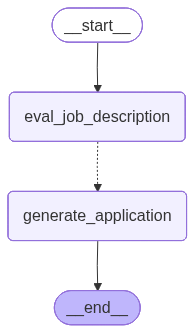

In [ ]:
from langchain_core.runnables.config import RunnableConfig

llms = {
    "fake": fake_llm,
    "Google": llm
}

def eval_job_description(state, config: RunnableConfig):
    try:
        print("Here")
        llm = config["configurable"].get("model_provider", "Google")
        analyse_chain = llm | parser
        prompt = prompt_template_enum.format(job_description=job_description)
        result = analyse_chain.invoke(prompt)
        return {"is_suitable": result}
    except Exception as e:
        logger.error(f"Exception {e} occured while executing eval_job_description")
        return {"is_suitable": False}

builder = StateGraph(JobApplicationState)

builder.add_node("eval_job_description", eval_job_description)
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "eval_job_description")
builder.add_conditional_edges("eval_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png(wrap_label_n_words=20)))

In [ ]:
res = graph.invoke({"job_description":"fake_jd"}, config={"configurable": {"model_provider": "fake"}})
print(res)

Exception Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'str'> occured while executing eval_job_description


Here
{'job_description': 'fake_jd', 'is_suitable': False, 'actions': []}


## With Retry Attempts
Different ways to create retry attempts

In [ ]:
analyse_chain_fake = fake_llm | parser

fake_llm_try = fake_llm.with_retry(
    retry_if_exception_type=(ValueError,),
    wait_exponential_jitter=True,
    stop_after_attempt=2,
)

analyse_chain_fake_retries = fake_llm_try | parser

In [ ]:
analyse_chain_fake_retries = (fake_llm | parser).with_retry(
    retry_if_exception_type=(ValueError,),
    wait_exponential_jitter=True,
    stop_after_attempt=2,
)

In [ ]:
analyse_chain_fake_retries.invoke("test")

<IsSuitableJobEnum.YES: 'YES'>

## Retry within tool calling node

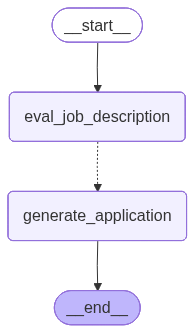

In [ ]:
from langgraph.pregel import RetryPolicy

def eval_job_description(state: JobApplicationState, config: RunnableConfig):
    model_provider = config["configurable"].get("model_provider", "Google")
    llm = llms[model_provider]
    analyse_chain = llm | parser
    prompt = prompt_template_enum.format(job_description=job_description)
    result = analyse_chain.invoke(prompt)
    return {"is_suitable": result}

builder = StateGraph(JobApplicationState)

builder.add_node("eval_job_description", eval_job_description, retry=RetryPolicy(retry_on=ValueError, max_attempts=2))
builder.add_node("generate_application", generate_application)

builder.add_edge(START, "eval_job_description")
builder.add_conditional_edges("eval_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke(
    {"job_description": job_description},
    config={"configurable": {"model_provider": "fake"}},
)
print(res)

...Generating Application...
{'job_description': 'test job description', 'is_suitable': <IsSuitableJobEnum.YES: 'YES'>, 'application': 'some_fake_application', 'actions': ['action2']}


In [ ]:
fake_llm.invoke("test")

AIMessage(content='YES', additional_kwargs={}, response_metadata={}, id='run--1dc4c7da-7a1f-4f2f-a6ed-a53fc4e61358-0')

In [ ]:
fake_llm.invoke("test")

ValueError: Something Went Wrong

In [ ]:
from langchain_core.runnables import RunnableLambda

chain_fallback = RunnableLambda(lambda _: print("Running Fallback"))
chain = fake_llm | RunnableLambda(lambda _: print("Running Main Chain"))
chain_with_fb = chain.with_fallbacks([chain_fallback])

Here we can see on second invoke it successfully calls the fallback on error

In [ ]:
chain_with_fb.invoke("test")
chain_with_fb.invoke("test")

Running Main Chain
Running Fallback
